# BMW Battery Thermal Memory Feature Analysis (0~240min)

이 노트북은 `bmw_feature_engineering.csv`를 불러와서,  
BSI(Battery Stress Index)에 넣을 **누적 Thermal Stress Feature**를 찾기 위한 분석 흐름입니다.

분석 목표:

1. 0~240분 범위에서 10분 단위 Rolling Power Feature 생성
2. Rolling Power와 현재 Thermal Feature의 상관관계 확인
3. Rolling Power와 미래 Temp Diff 간 Lag Mapping 분석
4. 유효 샘플 수 확인
5. 특정 구간 확대 분석
6. Plateau 지점 확인
7. BSI 후보 Thermal Memory Feature 선정


## 0. 라이브러리 불러오기

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. 데이터 불러오기

In [87]:
file_path = r"C:\Users\EL095\Microsoft\20260515\bmw_feature_engineering.csv"

df = pd.read_csv(file_path)

print(df.shape)
df.head()

(958885, 63)


,Time [s],Velocity [km/h],Elevation [m],Throttle [%],Motor Torque [Nm],Longitudinal Acceleration [m/s^2],Regenerative Braking Signal,Battery Voltage [V],Battery Current [A],Battery Temperature [°C],...,Delta_I,Delta_T,Battery_Power,Delta_P,dV_dt,dI_dt,dT_dt,dP_dt,Battery_Mode,Temp_Diff
0,0.0,0.0,574.0,0.0,0.0,-0.03,0.0,391.4,-2.20,21.0,...,NaN,NaN,-861.080,NaN,NaN,NaN,NaN,NaN,Discharging,-4.5
1,0.1,0.0,574.0,0.0,0.0,0.00,0.0,391.4,-2.21,21.0,...,-0.01,0.0,-864.994,-3.914,0.0,-0.1,0.0,-39.14,Discharging,-4.5
2,0.2,0.0,574.0,0.0,0.0,-0.01,0.0,391.4,-2.26,21.0,...,-0.05,0.0,-884.564,-19.570,0.0,-0.5,0.0,-195.70,Discharging,-4.5
3,0.3,0.0,574.0,0.0,0.0,-0.03,0.0,391.4,-2.30,21.0,...,-0.04,0.0,-900.220,-15.656,0.0,-0.4,0.0,-156.56,Discharging,-4.5
4,0.4,0.0,574.0,0.0,0.0,-0.03,0.0,391.4,-2.30,21.0,...,0.00,0.0,-900.220,0.000,0.0,0.0,0.0,0.00,Discharging,-4.5


In [88]:
# TripB 데이터만 필터링
df = df[df["source_file"].astype(str).str.contains("TripB", case=False, na=False)].copy()

print("TripB only shape:", df.shape)
df["source_file"].unique()[:10]

TripB only shape: (491184, 63)


<StringArray>
['TripB01.csv', 'TripB02.csv', 'TripB03.csv', 'TripB04.csv', 'TripB05.csv',
 'TripB06.csv', 'TripB07.csv', 'TripB08.csv', 'TripB09.csv', 'TripB10.csv']
Length: 10, dtype: str

## 2. 필요한 컬럼 선택

In [89]:
use_cols = [
    "Time [s]",
    "source_file",
    "Battery Voltage [V]",
    "Battery Current [A]",
    "Battery Temperature [°C]",
    "Ambient Temperature [°C]",
    "Delta_t",
    "Delta_V",
    "Delta_I",
    "Delta_T",
    "Battery_Power",
    "Delta_P",
    "dV_dt",
    "dI_dt",
    "dT_dt",
    "dP_dt",
    "Battery_Mode",
    "Temp_Diff"
]

df = df[use_cols].copy()

df.head()

,Time [s],source_file,Battery Voltage [V],Battery Current [A],Battery Temperature [°C],Ambient Temperature [°C],Delta_t,Delta_V,Delta_I,Delta_T,Battery_Power,Delta_P,dV_dt,dI_dt,dT_dt,dP_dt,Battery_Mode,Temp_Diff
467701,0.0,TripB01.csv,388.8,-19.06128,7.0,8.5,-1672.1,12.4,-16.62128,-19.0,-7411.025664,-6492.609664,-0.007416,0.00994,0.011363,3.882908,Discharging,-1.5
467702,0.1,TripB01.csv,388.8,-19.06128,7.0,8.5,0.1,0.0,0.00000,0.0,-7411.025664,0.000000,0.000000,0.00000,0.000000,0.000000,Discharging,-1.5
467703,0.2,TripB01.csv,388.8,-18.86127,7.0,8.5,0.1,0.0,0.20001,0.0,-7333.261776,77.763888,0.000000,2.00010,0.000000,777.638880,Discharging,-1.5
467704,0.3,TripB01.csv,388.8,-18.69031,7.0,8.5,0.1,0.0,0.17096,0.0,-7266.792528,66.469248,0.000000,1.70960,0.000000,664.692480,Discharging,-1.5
467705,0.4,TripB01.csv,388.8,-18.64031,7.0,8.5,0.1,0.0,0.05000,0.0,-7247.352528,19.440000,0.000000,0.50000,0.000000,194.400000,Discharging,-1.5


## 3. 컬럼명 정리

In [90]:
df = df.rename(columns={
    "Time [s]": "time",
    "source_file": "source",
    "Battery Voltage [V]": "voltage",
    "Battery Current [A]": "current",
    "Battery Temperature [°C]": "battery_temp",
    "Ambient Temperature [°C]": "ambient_temp",
    "Delta_t": "delta_t",
    "Delta_V": "delta_v",
    "Delta_I": "delta_i",
    "Delta_T": "delta_t_temp",
    "Battery_Power": "power",
    "Delta_P": "delta_p",
    "dV_dt": "dv_dt",
    "dI_dt": "di_dt",
    "dT_dt": "dt_dt",
    "dP_dt": "dp_dt",
    "Battery_Mode": "mode",
    "Temp_Diff": "temp_diff"
})

df.head()

,time,source,voltage,current,battery_temp,ambient_temp,delta_t,delta_v,delta_i,delta_t_temp,power,delta_p,dv_dt,di_dt,dt_dt,dp_dt,mode,temp_diff
467701,0.0,TripB01.csv,388.8,-19.06128,7.0,8.5,-1672.1,12.4,-16.62128,-19.0,-7411.025664,-6492.609664,-0.007416,0.00994,0.011363,3.882908,Discharging,-1.5
467702,0.1,TripB01.csv,388.8,-19.06128,7.0,8.5,0.1,0.0,0.00000,0.0,-7411.025664,0.000000,0.000000,0.00000,0.000000,0.000000,Discharging,-1.5
467703,0.2,TripB01.csv,388.8,-18.86127,7.0,8.5,0.1,0.0,0.20001,0.0,-7333.261776,77.763888,0.000000,2.00010,0.000000,777.638880,Discharging,-1.5
467704,0.3,TripB01.csv,388.8,-18.69031,7.0,8.5,0.1,0.0,0.17096,0.0,-7266.792528,66.469248,0.000000,1.70960,0.000000,664.692480,Discharging,-1.5
467705,0.4,TripB01.csv,388.8,-18.64031,7.0,8.5,0.1,0.0,0.05000,0.0,-7247.352528,19.440000,0.000000,0.50000,0.000000,194.400000,Discharging,-1.5


## 4. 기본 정렬 및 결측치 확인

In [91]:
df = df.sort_values(["source", "time"]).reset_index(drop=True)

print(df.shape)
print(df.isnull().sum())

(491184, 18)
time            0
source          0
voltage         0
current         0
battery_temp    0
ambient_temp    0
delta_t         0
delta_v         0
delta_i         0
delta_t_temp    0
power           0
delta_p         0
dv_dt           0
di_dt           0
dt_dt           0
dp_dt           0
mode            0
temp_diff       0
dtype: int64


## 5. 분석용 데이터프레임 생성

In [92]:
analysis_df = df.copy()

# 시간 역전이나 비정상 delta_t 제거
analysis_df = analysis_df[analysis_df["delta_t"] > 0].copy()

# 물리적으로 불가능한 값 제거
analysis_df = analysis_df[
    (analysis_df["voltage"] > 0) &
    (analysis_df["battery_temp"] > -50) &
    (analysis_df["battery_temp"] < 100)
].copy()

analysis_df = analysis_df.reset_index(drop=True)

print(analysis_df.shape)
analysis_df.head()

(491156, 18)


,time,source,voltage,current,battery_temp,ambient_temp,delta_t,delta_v,delta_i,delta_t_temp,power,delta_p,dv_dt,di_dt,dt_dt,dp_dt,mode,temp_diff
0,0.1,TripB01.csv,388.8,-19.06128,7.0,8.5,0.1,0.0,0.00000,0.0,-7411.025664,0.000000,0.0,0.0000,0.0,0.00000,Discharging,-1.5
1,0.2,TripB01.csv,388.8,-18.86127,7.0,8.5,0.1,0.0,0.20001,0.0,-7333.261776,77.763888,0.0,2.0001,0.0,777.63888,Discharging,-1.5
2,0.3,TripB01.csv,388.8,-18.69031,7.0,8.5,0.1,0.0,0.17096,0.0,-7266.792528,66.469248,0.0,1.7096,0.0,664.69248,Discharging,-1.5
3,0.4,TripB01.csv,388.8,-18.64031,7.0,8.5,0.1,0.0,0.05000,0.0,-7247.352528,19.440000,0.0,0.5000,0.0,194.40000,Discharging,-1.5
4,0.5,TripB01.csv,388.8,-18.58062,7.0,8.5,0.1,0.0,0.05969,0.0,-7224.145056,23.207472,0.0,0.5969,0.0,232.07472,Discharging,-1.5


## 6. 전력 절댓값 생성

In [93]:
# Thermal stress는 충전/방전 방향보다 부하의 크기가 중요하므로 절댓값 사용
analysis_df["abs_power"] = analysis_df["power"].abs()

analysis_df[["power", "abs_power"]].head()

,power,abs_power
0,-7411.025664,7411.025664
1,-7333.261776,7333.261776
2,-7266.792528,7266.792528
3,-7247.352528,7247.352528
4,-7224.145056,7224.145056


## 7. 데이터 시간 간격 확인

In [94]:
dt = analysis_df["delta_t"].median()

print("Median delta_t:", dt)
print("Sampling interval:", dt, "seconds")

Median delta_t: 0.0999999999999996
Sampling interval: 0.0999999999999996 seconds


## 8. 0~240분까지 10분 단위 Rolling Power 생성

In [95]:
rolling_minutes_list = list(range(10, 241, 10))

# 0분은 rolling이 아니라 현재 순간 전력 절댓값으로 간주
rolling_power_cols = ["abs_power"]

for minute in rolling_minutes_list:
    window_seconds = minute * 60
    window_size = int(window_seconds / dt)

    col_name = f"rolling_abs_power_{minute}min"

    analysis_df[col_name] = (
        analysis_df
        .groupby("source")["abs_power"]
        .transform(
            lambda x: x.rolling(
                window=window_size,
                min_periods=1
            ).mean()
        )
    )

    rolling_power_cols.append(col_name)

print(rolling_power_cols[:5])
print(rolling_power_cols[-5:])

['abs_power', 'rolling_abs_power_10min', 'rolling_abs_power_20min', 'rolling_abs_power_30min', 'rolling_abs_power_40min']
['rolling_abs_power_200min', 'rolling_abs_power_210min', 'rolling_abs_power_220min', 'rolling_abs_power_230min', 'rolling_abs_power_240min']


## 9. 현재 시점 Thermal Feature와 상관관계 보기

In [96]:
thermal_cols = [
    "battery_temp",
    "temp_diff",
    "delta_t_temp"
]

corr_current_thermal = analysis_df[
    rolling_power_cols + thermal_cols
].corr().loc[
    rolling_power_cols,
    thermal_cols
]

corr_current_thermal

,battery_temp,temp_diff,delta_t_temp
abs_power,0.024973,-0.037835,0.029658
rolling_abs_power_10min,0.161597,0.017875,0.004555
rolling_abs_power_20min,0.223030,0.054992,0.003427
rolling_abs_power_30min,0.249631,0.081819,0.003365
rolling_abs_power_40min,0.259689,0.099765,0.003616
rolling_abs_power_50min,0.267398,0.113476,0.004171
rolling_abs_power_60min,0.267209,0.117997,0.004699
rolling_abs_power_70min,0.267805,0.123385,0.005189
rolling_abs_power_80min,0.268088,0.126610,0.005471
rolling_abs_power_90min,0.268293,0.128247,0.005612


## 10. 현재 Thermal Feature 상관관계 Heatmap

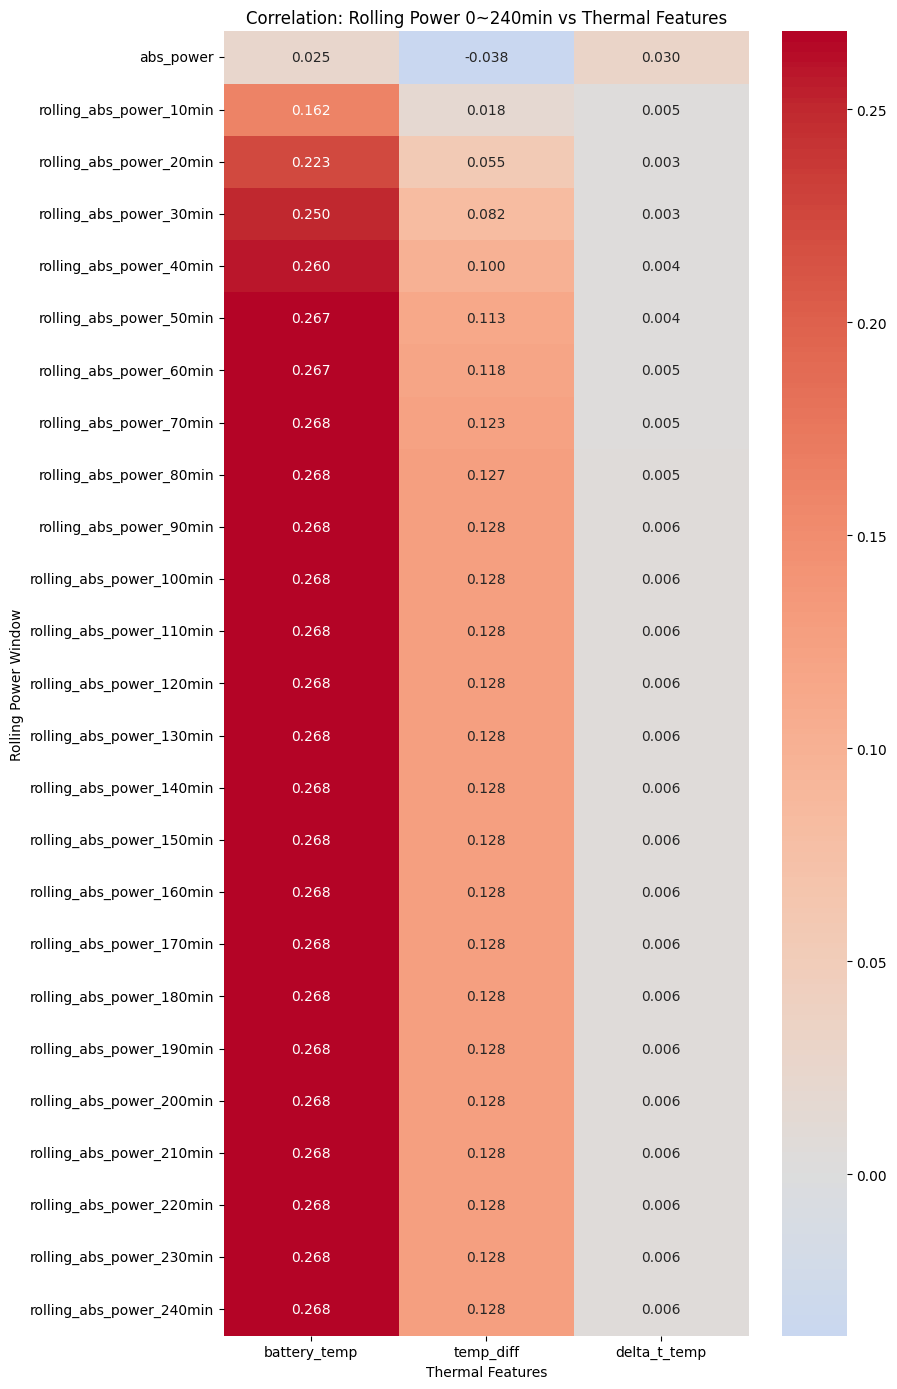

In [97]:
plt.figure(figsize=(9, 14))

sns.heatmap(
    corr_current_thermal,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".3f"
)

plt.title("Correlation: Rolling Power 0~240min vs Thermal Features")
plt.xlabel("Thermal Features")
plt.ylabel("Rolling Power Window")

plt.tight_layout()
plt.show()

## 11. Thermal Feature별 선그래프

### 11.1 Rolling Power와 Battery Temperature

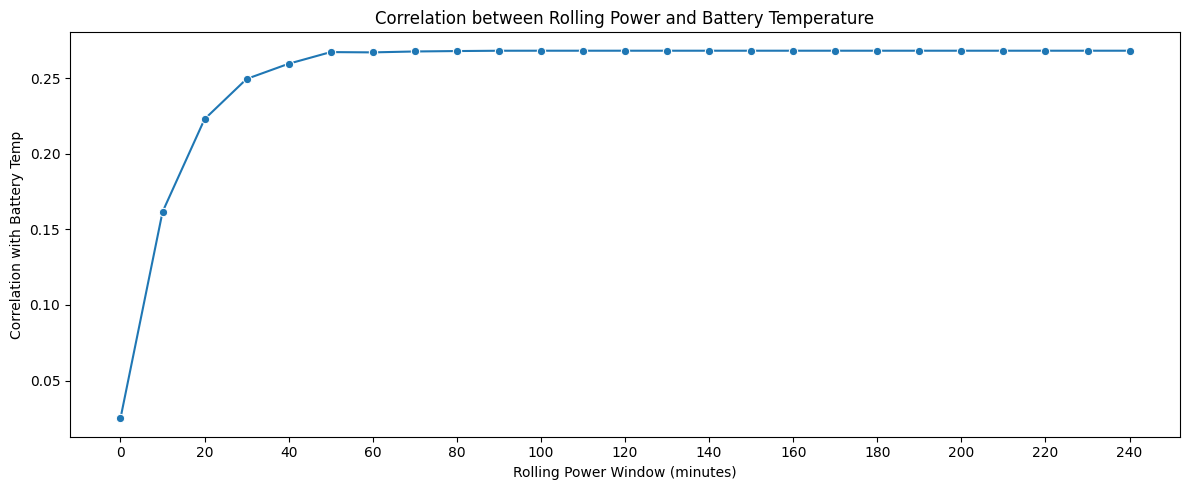

,feature,corr_with_battery_temp,window_min
0,abs_power,0.024973,0
1,rolling_abs_power_10min,0.161597,10
2,rolling_abs_power_20min,0.223030,20
3,rolling_abs_power_30min,0.249631,30
4,rolling_abs_power_40min,0.259689,40
5,rolling_abs_power_50min,0.267398,50
6,rolling_abs_power_60min,0.267209,60
7,rolling_abs_power_70min,0.267805,70
8,rolling_abs_power_80min,0.268088,80
9,rolling_abs_power_90min,0.268293,90


In [98]:
battery_temp_corr = corr_current_thermal["battery_temp"].reset_index()
battery_temp_corr.columns = ["feature", "corr_with_battery_temp"]

battery_temp_corr["window_min"] = battery_temp_corr["feature"].replace({
    "abs_power": "0"
}).str.extract(r"(\d+)").astype(int)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=battery_temp_corr,
    x="window_min",
    y="corr_with_battery_temp",
    marker="o"
)

plt.title("Correlation between Rolling Power and Battery Temperature")
plt.xlabel("Rolling Power Window (minutes)")
plt.ylabel("Correlation with Battery Temp")

plt.xticks(list(range(0, 241, 20)))
plt.tight_layout()
plt.show()

battery_temp_corr

### 11.2 Rolling Power와 Temp Diff

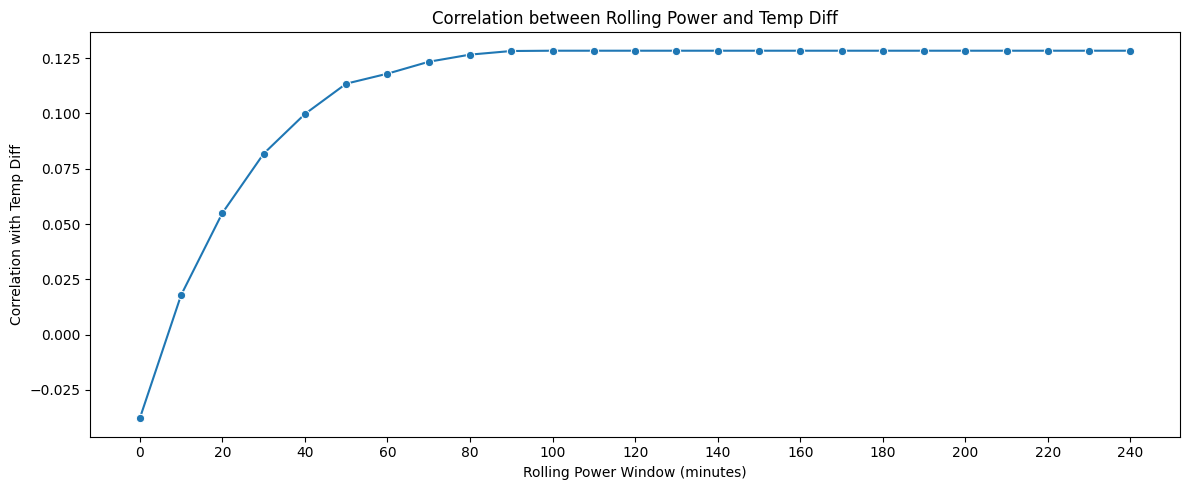

,feature,corr_with_temp_diff,window_min
0,abs_power,-0.037835,0
1,rolling_abs_power_10min,0.017875,10
2,rolling_abs_power_20min,0.054992,20
3,rolling_abs_power_30min,0.081819,30
4,rolling_abs_power_40min,0.099765,40
5,rolling_abs_power_50min,0.113476,50
6,rolling_abs_power_60min,0.117997,60
7,rolling_abs_power_70min,0.123385,70
8,rolling_abs_power_80min,0.126610,80
9,rolling_abs_power_90min,0.128247,90


In [99]:
temp_diff_corr = corr_current_thermal["temp_diff"].reset_index()
temp_diff_corr.columns = ["feature", "corr_with_temp_diff"]

temp_diff_corr["window_min"] = temp_diff_corr["feature"].replace({
    "abs_power": "0"
}).str.extract(r"(\d+)").astype(int)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=temp_diff_corr,
    x="window_min",
    y="corr_with_temp_diff",
    marker="o"
)

plt.title("Correlation between Rolling Power and Temp Diff")
plt.xlabel("Rolling Power Window (minutes)")
plt.ylabel("Correlation with Temp Diff")

plt.xticks(list(range(0, 241, 20)))
plt.tight_layout()
plt.show()

temp_diff_corr

### 11.3 Rolling Power와 Delta Temperature

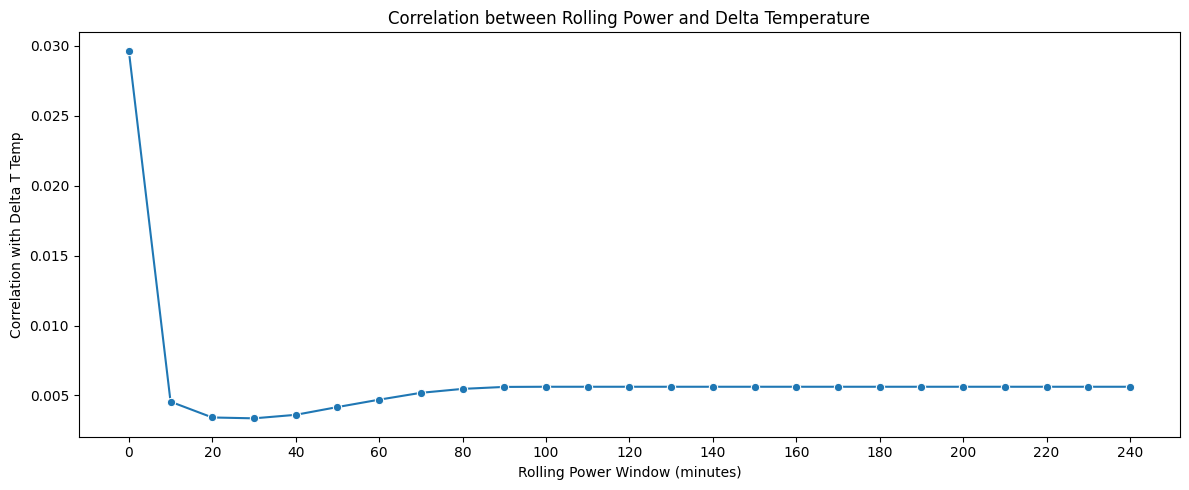

,feature,corr_with_delta_t_temp,window_min
0,abs_power,0.029658,0
1,rolling_abs_power_10min,0.004555,10
2,rolling_abs_power_20min,0.003427,20
3,rolling_abs_power_30min,0.003365,30
4,rolling_abs_power_40min,0.003616,40
5,rolling_abs_power_50min,0.004171,50
6,rolling_abs_power_60min,0.004699,60
7,rolling_abs_power_70min,0.005189,70
8,rolling_abs_power_80min,0.005471,80
9,rolling_abs_power_90min,0.005612,90


In [100]:
delta_temp_corr = corr_current_thermal["delta_t_temp"].reset_index()
delta_temp_corr.columns = ["feature", "corr_with_delta_t_temp"]

delta_temp_corr["window_min"] = delta_temp_corr["feature"].replace({
    "abs_power": "0"
}).str.extract(r"(\d+)").astype(int)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=delta_temp_corr,
    x="window_min",
    y="corr_with_delta_t_temp",
    marker="o"
)

plt.title("Correlation between Rolling Power and Delta Temperature")
plt.xlabel("Rolling Power Window (minutes)")
plt.ylabel("Correlation with Delta T Temp")

plt.xticks(list(range(0, 241, 20)))
plt.tight_layout()
plt.show()

delta_temp_corr

## 12. Future Temp Diff 생성: 10~240분 후

In [101]:
lag_minutes_list = list(range(10, 241, 10))

for lag_minute in lag_minutes_list:
    lag_seconds = lag_minute * 60
    lag_steps = int(lag_seconds / dt)

    future_col = f"temp_diff_future_{lag_minute}min"

    analysis_df[future_col] = (
        analysis_df
        .groupby("source")["temp_diff"]
        .shift(-lag_steps)
    )

print([f"temp_diff_future_{m}min" for m in lag_minutes_list[:5]])
print([f"temp_diff_future_{m}min" for m in lag_minutes_list[-5:]])

['temp_diff_future_10min', 'temp_diff_future_20min', 'temp_diff_future_30min', 'temp_diff_future_40min', 'temp_diff_future_50min']
['temp_diff_future_200min', 'temp_diff_future_210min', 'temp_diff_future_220min', 'temp_diff_future_230min', 'temp_diff_future_240min']


## 13. Rolling Window × Future Lag Mapping 전체 분석

In [102]:
lag_mapping_results = []

for rolling_minute in rolling_minutes_list:
    power_col = f"rolling_abs_power_{rolling_minute}min"

    for lag_minute in lag_minutes_list:
        future_col = f"temp_diff_future_{lag_minute}min"

        temp_df = analysis_df[[power_col, future_col]].dropna()

        if len(temp_df) > 2:
            corr_value = temp_df[power_col].corr(temp_df[future_col])
        else:
            corr_value = np.nan

        lag_mapping_results.append({
            "rolling_power_window_min": rolling_minute,
            "future_lag_min": lag_minute,
            "corr": corr_value,
            "valid_sample_count": len(temp_df)
        })

lag_mapping_df = pd.DataFrame(lag_mapping_results)

lag_mapping_df.head()

c:\Users\EL095\Microsoft\20260515\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\EL095\Microsoft\20260515\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,rolling_power_window_min,future_lag_min,corr,valid_sample_count
0,10,10,0.074353,330465
1,10,20,0.121717,192168
2,10,30,0.135750,117132
3,10,40,0.194777,73780
4,10,50,-0.226788,39092


## 14. Lag Mapping Pivot Table

In [103]:
lag_mapping_pivot = lag_mapping_df.pivot(
    index="rolling_power_window_min",
    columns="future_lag_min",
    values="corr"
)

lag_mapping_pivot

future_lag_min,10,20,30,40,50,60,70,80,90,100,...,150,160,170,180,190,200,210,220,230,240
rolling_power_window_min,,,,,,,,,,,,,,,,,,,,,
10,0.074353,0.121717,0.135750,0.194777,-0.226788,-0.492836,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,0.126528,0.187943,0.260952,0.221422,-0.224863,-0.563092,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,0.160354,0.248566,0.282912,0.279212,-0.212025,-0.566413,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40,0.190422,0.269626,0.323101,0.305913,-0.200994,-0.568613,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,0.201421,0.294799,0.343173,0.323853,-0.200184,-0.568613,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,0.213737,0.308934,0.356781,0.325294,-0.200184,-0.568613,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70,0.221136,0.317794,0.358287,0.325294,-0.200184,-0.568613,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,0.225149,0.318599,0.358287,0.325294,-0.200184,-0.568613,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
90,0.225485,0.318599,0.358287,0.325294,-0.200184,-0.568613,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 15. Lag Mapping Heatmap: 0~240분 전체

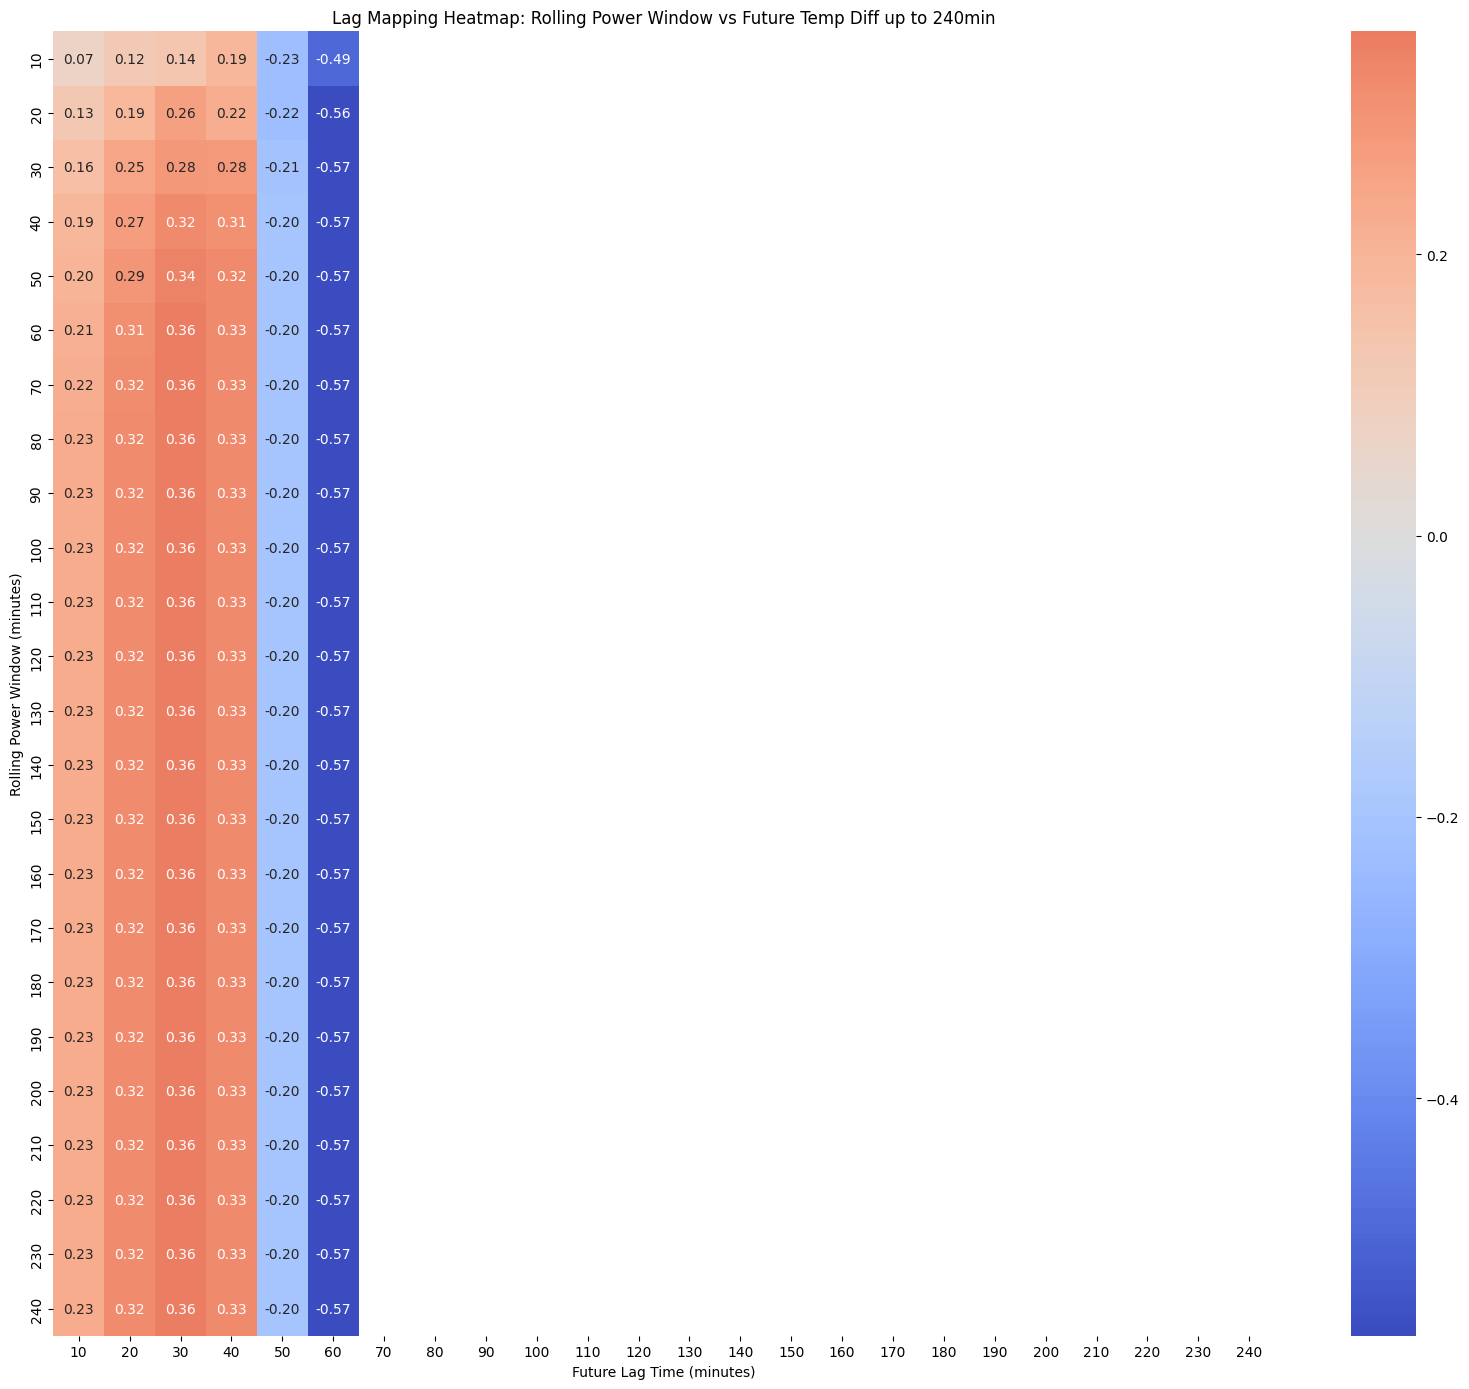

In [104]:
plt.figure(figsize=(16, 14))

sns.heatmap(
    lag_mapping_pivot,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Lag Mapping Heatmap: Rolling Power Window vs Future Temp Diff up to 240min")
plt.xlabel("Future Lag Time (minutes)")
plt.ylabel("Rolling Power Window (minutes)")

plt.tight_layout()
plt.show()

## 16. 유효 샘플 수 확인

In [105]:
sample_count_pivot = lag_mapping_df.pivot(
    index="rolling_power_window_min",
    columns="future_lag_min",
    values="valid_sample_count"
)

sample_count_pivot

future_lag_min,10,20,30,40,50,60,70,80,90,100,...,150,160,170,180,190,200,210,220,230,240
rolling_power_window_min,,,,,,,,,,,,,,,,,,,,,
10,330465,192168,117132,73780,39092,22320,14101,8101,2101,0,...,0,0,0,0,0,0,0,0,0,0
20,330465,192168,117132,73780,39092,22320,14101,8101,2101,0,...,0,0,0,0,0,0,0,0,0,0
30,330465,192168,117132,73780,39092,22320,14101,8101,2101,0,...,0,0,0,0,0,0,0,0,0,0
40,330465,192168,117132,73780,39092,22320,14101,8101,2101,0,...,0,0,0,0,0,0,0,0,0,0
50,330465,192168,117132,73780,39092,22320,14101,8101,2101,0,...,0,0,0,0,0,0,0,0,0,0
60,330465,192168,117132,73780,39092,22320,14101,8101,2101,0,...,0,0,0,0,0,0,0,0,0,0
70,330465,192168,117132,73780,39092,22320,14101,8101,2101,0,...,0,0,0,0,0,0,0,0,0,0
80,330465,192168,117132,73780,39092,22320,14101,8101,2101,0,...,0,0,0,0,0,0,0,0,0,0
90,330465,192168,117132,73780,39092,22320,14101,8101,2101,0,...,0,0,0,0,0,0,0,0,0,0


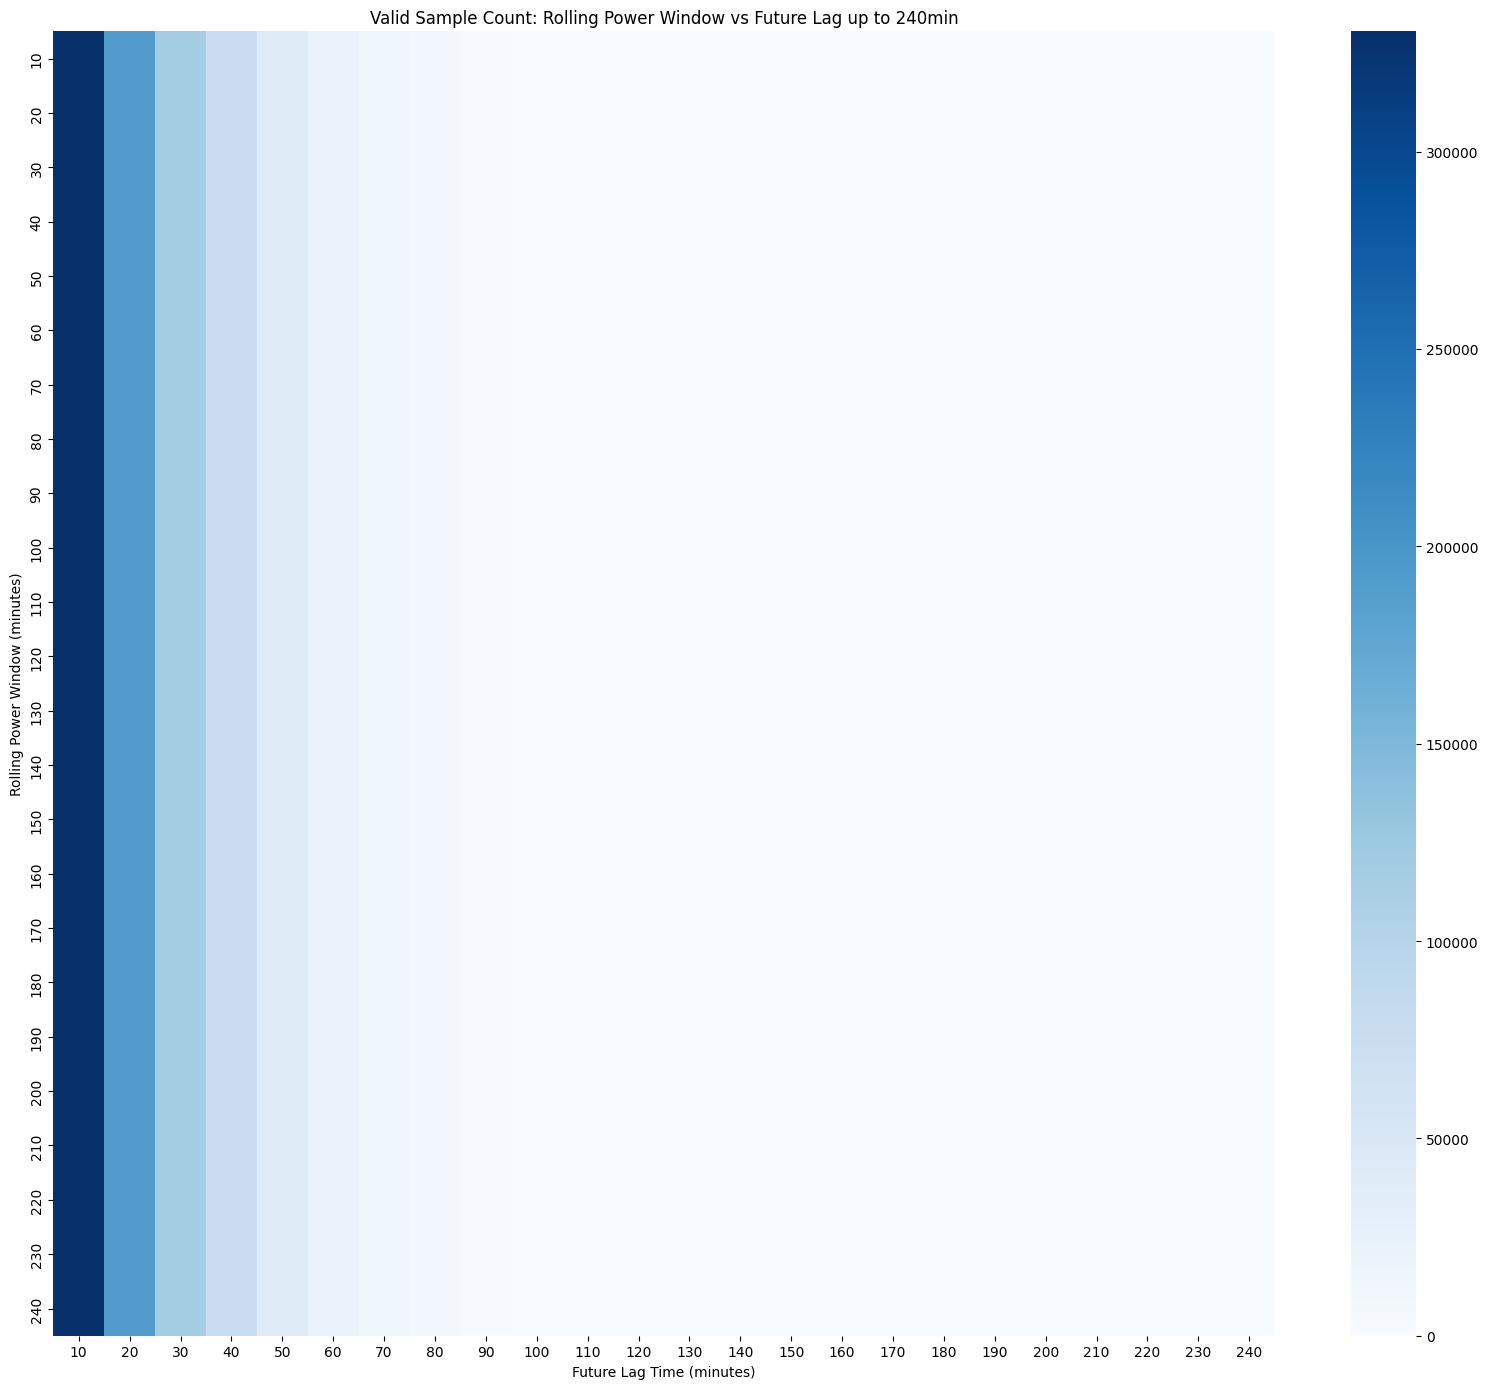

In [106]:
plt.figure(figsize=(16, 14))

sns.heatmap(
    sample_count_pivot,
    annot=False,
    cmap="Blues"
)

plt.title("Valid Sample Count: Rolling Power Window vs Future Lag up to 240min")
plt.xlabel("Future Lag Time (minutes)")
plt.ylabel("Rolling Power Window (minutes)")

plt.tight_layout()
plt.show()

## 17. 전체 구간에서 가장 높은 양의 상관관계 찾기

In [107]:
best_positive = lag_mapping_df.loc[
    lag_mapping_df["corr"].idxmax()
]

best_positive

rolling_power_window_min        70.000000
future_lag_min                  30.000000
corr                             0.358287
valid_sample_count          117132.000000
Name: 146, dtype: float64

In [108]:
print("가장 높은 양의 상관관계")
print("Rolling Power Window:", best_positive["rolling_power_window_min"], "분")
print("Future Lag Time:", best_positive["future_lag_min"], "분 후")
print("Correlation:", best_positive["corr"])
print("Valid Sample Count:", best_positive["valid_sample_count"])

가장 높은 양의 상관관계
Rolling Power Window: 70.0 분
Future Lag Time: 30.0 분 후
Correlation: 0.358287429876887
Valid Sample Count: 117132.0


## 18. 전체 구간에서 가장 낮은 음의 상관관계 찾기

In [109]:
best_negative = lag_mapping_df.loc[
    lag_mapping_df["corr"].idxmin()
]

best_negative

rolling_power_window_min       40.000000
future_lag_min                 60.000000
corr                           -0.568613
valid_sample_count          22320.000000
Name: 77, dtype: float64

In [110]:
print("가장 낮은 음의 상관관계")
print("Rolling Power Window:", best_negative["rolling_power_window_min"], "분")
print("Future Lag Time:", best_negative["future_lag_min"], "분 후")
print("Correlation:", best_negative["corr"])
print("Valid Sample Count:", best_negative["valid_sample_count"])

가장 낮은 음의 상관관계
Rolling Power Window: 40.0 분
Future Lag Time: 60.0 분 후
Correlation: -0.568612825857189
Valid Sample Count: 22320.0


## 19. Rolling Window별 최고 상관관계 정리

In [111]:
max_corr_by_window = []

for rolling_minute in rolling_minutes_list:
    temp = lag_mapping_df[
        lag_mapping_df["rolling_power_window_min"] == rolling_minute
    ].dropna(subset=["corr"])

    if len(temp) > 0:
        best_row = temp.loc[temp["corr"].idxmax()]

        max_corr_by_window.append({
            "rolling_power_window_min": rolling_minute,
            "best_lag_min": best_row["future_lag_min"],
            "max_corr": best_row["corr"],
            "valid_sample_count": best_row["valid_sample_count"]
        })

max_corr_by_window_df = pd.DataFrame(max_corr_by_window)

max_corr_by_window_df

,rolling_power_window_min,best_lag_min,max_corr,valid_sample_count
0,10,40.0,0.194777,73780.0
1,20,30.0,0.260952,117132.0
2,30,30.0,0.282912,117132.0
3,40,30.0,0.323101,117132.0
4,50,30.0,0.343173,117132.0
5,60,30.0,0.356781,117132.0
6,70,30.0,0.358287,117132.0
7,80,30.0,0.358287,117132.0
8,90,30.0,0.358287,117132.0
9,100,30.0,0.358287,117132.0


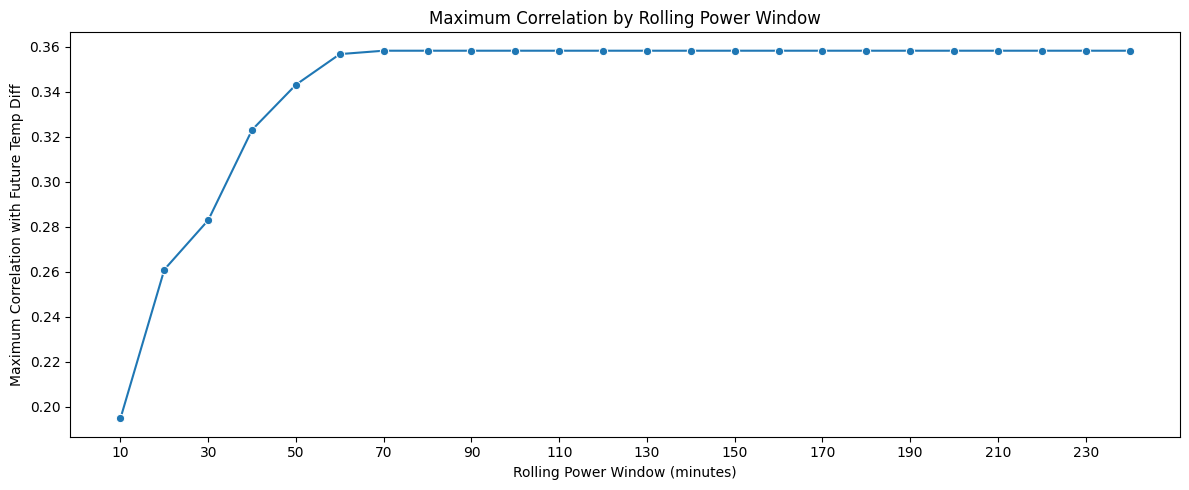

In [112]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=max_corr_by_window_df,
    x="rolling_power_window_min",
    y="max_corr",
    marker="o"
)

plt.title("Maximum Correlation by Rolling Power Window")
plt.xlabel("Rolling Power Window (minutes)")
plt.ylabel("Maximum Correlation with Future Temp Diff")

plt.xticks(list(range(10, 241, 20)))
plt.tight_layout()
plt.show()

## 20. Future Lag별 최고 상관관계 정리

In [113]:
max_corr_by_lag = []

for lag_minute in lag_minutes_list:
    temp = lag_mapping_df[
        lag_mapping_df["future_lag_min"] == lag_minute
    ].dropna(subset=["corr"])

    if len(temp) > 0:
        best_row = temp.loc[temp["corr"].idxmax()]

        max_corr_by_lag.append({
            "future_lag_min": lag_minute,
            "best_rolling_window_min": best_row["rolling_power_window_min"],
            "max_corr": best_row["corr"],
            "valid_sample_count": best_row["valid_sample_count"]
        })

max_corr_by_lag_df = pd.DataFrame(max_corr_by_lag)

max_corr_by_lag_df

,future_lag_min,best_rolling_window_min,max_corr,valid_sample_count
0,10,90.0,0.225485,330465.0
1,20,80.0,0.318599,192168.0
2,30,70.0,0.358287,117132.0
3,40,60.0,0.325294,73780.0
4,50,50.0,-0.200184,39092.0
5,60,10.0,-0.492836,22320.0


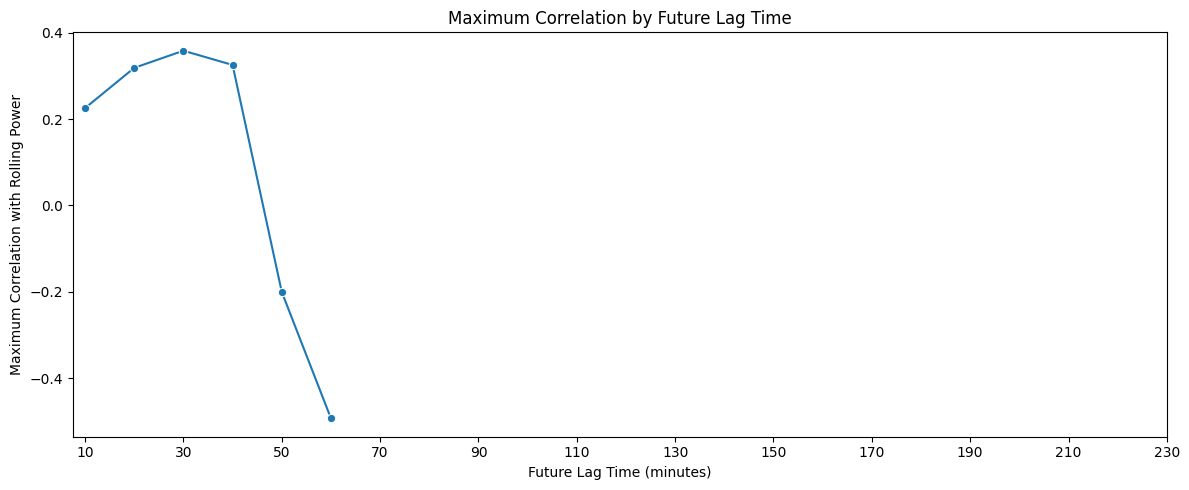

In [114]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=max_corr_by_lag_df,
    x="future_lag_min",
    y="max_corr",
    marker="o"
)

plt.title("Maximum Correlation by Future Lag Time")
plt.xlabel("Future Lag Time (minutes)")
plt.ylabel("Maximum Correlation with Rolling Power")

plt.xticks(list(range(10, 241, 20)))
plt.tight_layout()
plt.show()

## 21. 특정 구간 확대해서 보기

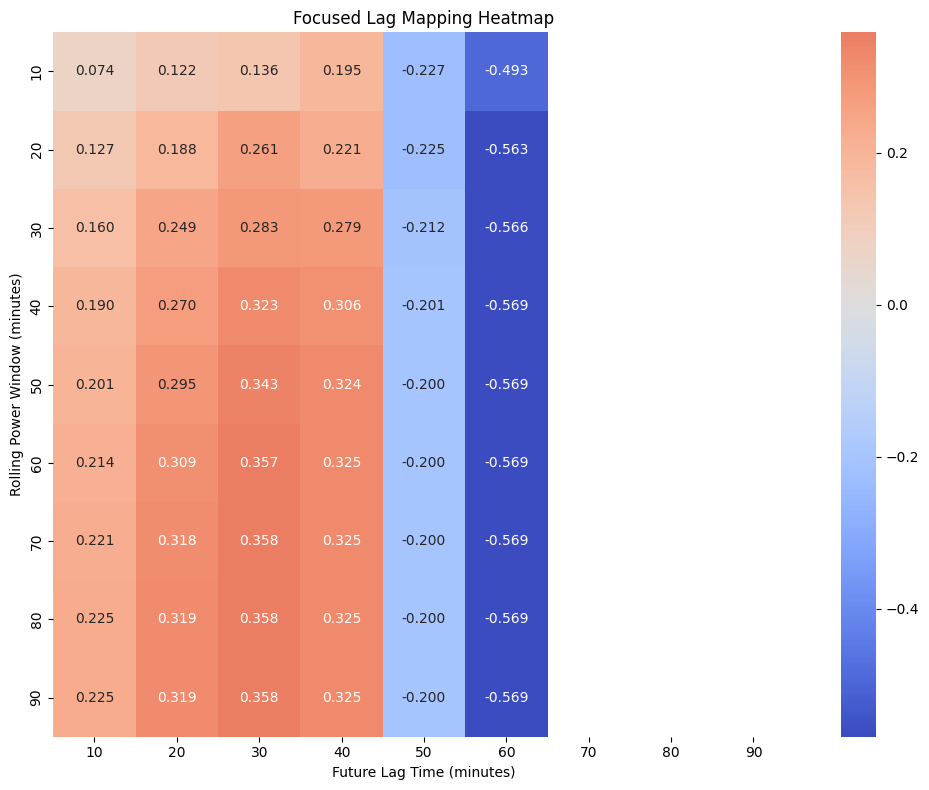

future_lag_min,10,20,30,40,50,60,70,80,90
rolling_power_window_min,,,,,,,,,
10,0.074353,0.121717,0.135750,0.194777,-0.226788,-0.492836,NaN,NaN,NaN
20,0.126528,0.187943,0.260952,0.221422,-0.224863,-0.563092,NaN,NaN,NaN
30,0.160354,0.248566,0.282912,0.279212,-0.212025,-0.566413,NaN,NaN,NaN
40,0.190422,0.269626,0.323101,0.305913,-0.200994,-0.568613,NaN,NaN,NaN
50,0.201421,0.294799,0.343173,0.323853,-0.200184,-0.568613,NaN,NaN,NaN
60,0.213737,0.308934,0.356781,0.325294,-0.200184,-0.568613,NaN,NaN,NaN
70,0.221136,0.317794,0.358287,0.325294,-0.200184,-0.568613,NaN,NaN,NaN
80,0.225149,0.318599,0.358287,0.325294,-0.200184,-0.568613,NaN,NaN,NaN
90,0.225485,0.318599,0.358287,0.325294,-0.200184,-0.568613,NaN,NaN,NaN


In [115]:
focus_window_min = 10
focus_window_max = 90

focus_lag_min = 10
focus_lag_max = 90

focus_df = lag_mapping_df[
    (lag_mapping_df["rolling_power_window_min"] >= focus_window_min) &
    (lag_mapping_df["rolling_power_window_min"] <= focus_window_max) &
    (lag_mapping_df["future_lag_min"] >= focus_lag_min) &
    (lag_mapping_df["future_lag_min"] <= focus_lag_max)
].copy()

focus_pivot = focus_df.pivot(
    index="rolling_power_window_min",
    columns="future_lag_min",
    values="corr"
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    focus_pivot,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".3f"
)

plt.title("Focused Lag Mapping Heatmap")
plt.xlabel("Future Lag Time (minutes)")
plt.ylabel("Rolling Power Window (minutes)")

plt.tight_layout()
plt.show()

focus_pivot

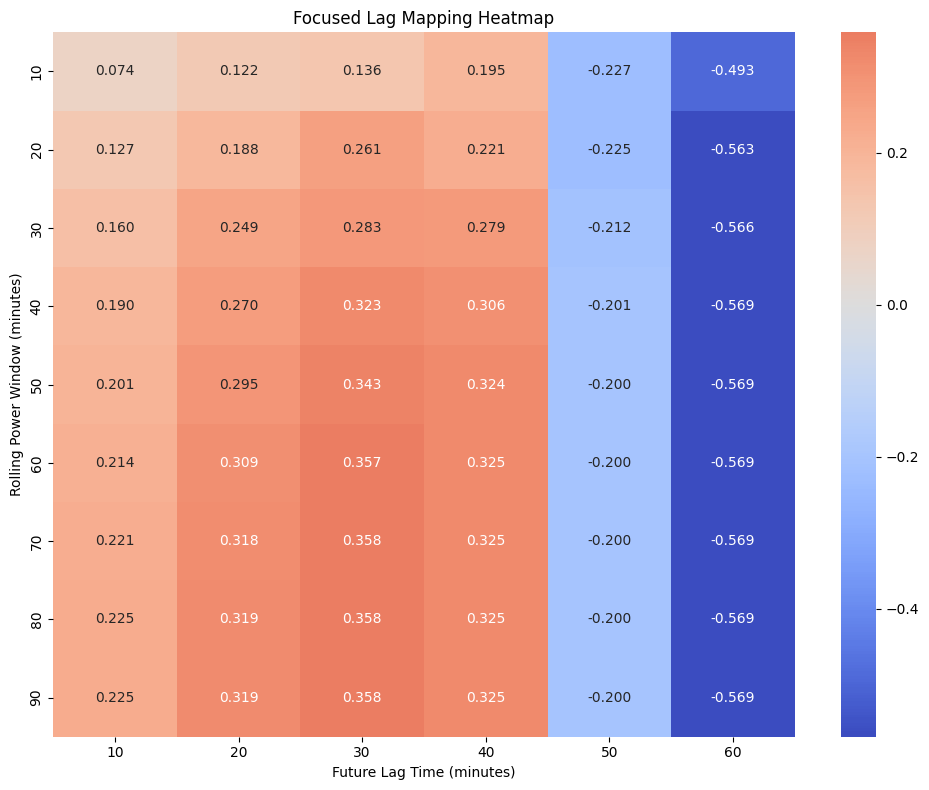

In [116]:
# =========================
# 6. Focused Lag Mapping Heatmap
# =========================

focused_df = lag_mapping_df[
    (lag_mapping_df["rolling_power_window_min"] <= 90) &
    (lag_mapping_df["future_lag_min"] <= 60)
]

focused_pivot = focused_df.pivot(
    index="rolling_power_window_min",
    columns="future_lag_min",
    values="corr"
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    focused_pivot,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0
)

plt.title("Focused Lag Mapping Heatmap")
plt.xlabel("Future Lag Time (minutes)")
plt.ylabel("Rolling Power Window (minutes)")

plt.tight_layout()
plt.show()

## 22. 특정 구간에서 최고 상관관계 찾기

In [117]:
focus_best = focus_df.loc[
    focus_df["corr"].idxmax()
]

print("특정 구간 내 최고 상관관계")
print("Rolling Power Window:", focus_best["rolling_power_window_min"], "분")
print("Future Lag Time:", focus_best["future_lag_min"], "분 후")
print("Correlation:", focus_best["corr"])
print("Valid Sample Count:", focus_best["valid_sample_count"])

특정 구간 내 최고 상관관계
Rolling Power Window: 70.0 분
Future Lag Time: 30.0 분 후
Correlation: 0.358287429876887
Valid Sample Count: 117132.0


## 23. Plateau 구간 자동 탐색

In [118]:
plateau_df = battery_temp_corr.copy()

plateau_df["corr_diff"] = plateau_df["corr_with_battery_temp"].diff()

plateau_df

,feature,corr_with_battery_temp,window_min,corr_diff
0,abs_power,0.024973,0,NaN
1,rolling_abs_power_10min,0.161597,10,0.136624
2,rolling_abs_power_20min,0.223030,20,0.061433
3,rolling_abs_power_30min,0.249631,30,0.026601
4,rolling_abs_power_40min,0.259689,40,0.010058
5,rolling_abs_power_50min,0.267398,50,0.007709
6,rolling_abs_power_60min,0.267209,60,-0.000189
7,rolling_abs_power_70min,0.267805,70,0.000596
8,rolling_abs_power_80min,0.268088,80,0.000283
9,rolling_abs_power_90min,0.268293,90,0.000205


In [119]:
threshold = 0.005

plateau_candidates = plateau_df[
    (plateau_df["window_min"] > 0) &
    (plateau_df["corr_diff"].abs() < threshold)
]

plateau_candidates.head()

,feature,corr_with_battery_temp,window_min,corr_diff
6,rolling_abs_power_60min,0.267209,60,-0.000189
7,rolling_abs_power_70min,0.267805,70,0.000596
8,rolling_abs_power_80min,0.268088,80,0.000283
9,rolling_abs_power_90min,0.268293,90,0.000205
10,rolling_abs_power_100min,0.268311,100,0.000018


In [120]:
if len(plateau_candidates) > 0:
    plateau_start = plateau_candidates.iloc[0]["window_min"]
    print("Plateau 시작 후보:", plateau_start, "분")
else:
    print("Plateau 후보 없음")

Plateau 시작 후보: 60 분


## 24. BSI 후보 Thermal Memory Feature 상관관계 확인

In [121]:
candidate_thermal_features = [
    "rolling_abs_power_50min",
    "rolling_abs_power_60min",
    "rolling_abs_power_70min",
    "rolling_abs_power_80min",
    "rolling_abs_power_90min"
]

candidate_thermal_features

['rolling_abs_power_50min',
 'rolling_abs_power_60min',
 'rolling_abs_power_70min',
 'rolling_abs_power_80min',
 'rolling_abs_power_90min']

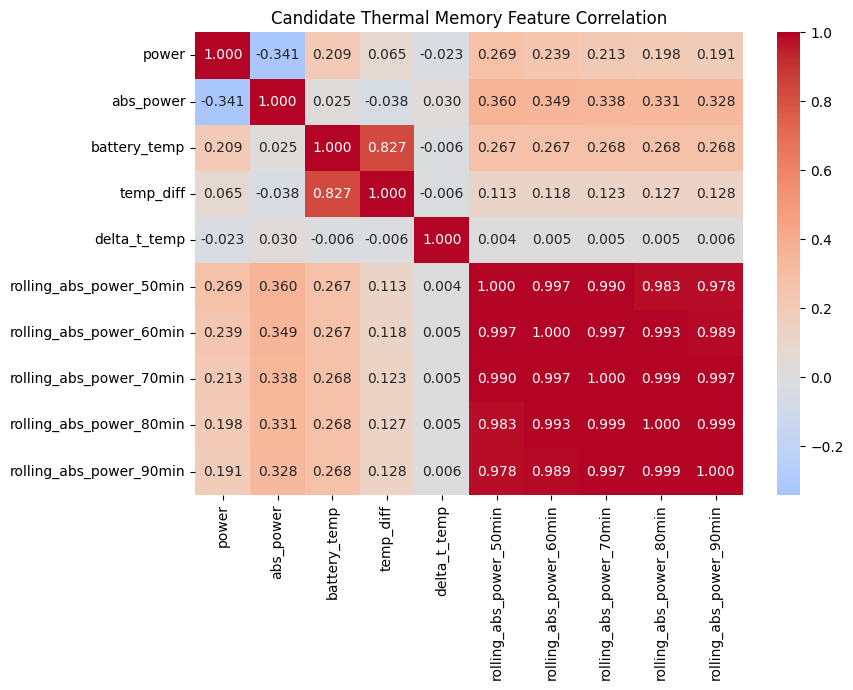

,power,abs_power,battery_temp,temp_diff,delta_t_temp,rolling_abs_power_50min,rolling_abs_power_60min,rolling_abs_power_70min,rolling_abs_power_80min,rolling_abs_power_90min
power,1.000000,-0.340544,0.208837,0.064638,-0.022668,0.268691,0.238704,0.213236,0.198250,0.190832
abs_power,-0.340544,1.000000,0.024973,-0.037835,0.029658,0.360483,0.348775,0.338022,0.331471,0.328286
battery_temp,0.208837,0.024973,1.000000,0.827249,-0.005821,0.267398,0.267209,0.267805,0.268088,0.268293
temp_diff,0.064638,-0.037835,0.827249,1.000000,-0.005555,0.113476,0.117997,0.123385,0.126610,0.128247
delta_t_temp,-0.022668,0.029658,-0.005821,-0.005555,1.000000,0.004171,0.004699,0.005189,0.005471,0.005612
rolling_abs_power_50min,0.268691,0.360483,0.267398,0.113476,0.004171,1.000000,0.996929,0.990071,0.982961,0.978184
rolling_abs_power_60min,0.238704,0.348775,0.267209,0.117997,0.004699,0.996929,1.000000,0.997488,0.993239,0.989463
rolling_abs_power_70min,0.213236,0.338022,0.267805,0.123385,0.005189,0.990071,0.997488,1.000000,0.998802,0.996915
rolling_abs_power_80min,0.198250,0.331471,0.268088,0.126610,0.005471,0.982961,0.993239,0.998802,1.000000,0.999406
rolling_abs_power_90min,0.190832,0.328286,0.268293,0.128247,0.005612,0.978184,0.989463,0.996915,0.999406,1.000000


In [122]:
candidate_cols = [
    "power",
    "abs_power",
    "battery_temp",
    "temp_diff",
    "delta_t_temp"
] + candidate_thermal_features

candidate_corr = analysis_df[candidate_cols].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    candidate_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".3f"
)

plt.title("Candidate Thermal Memory Feature Correlation")
plt.tight_layout()
plt.show()

candidate_corr

## 25. Feature 추가된 데이터 저장

In [123]:
output_path = r"C:\Users\EL095\Microsoft\20260515\bmw_with_rolling_thermal_features.csv"

analysis_df.to_csv(output_path, index=False, encoding="utf-8-sig")

print("저장 완료:", output_path)

저장 완료: C:\Users\EL095\Microsoft\20260515\bmw_with_rolling_thermal_features.csv


## 해석 메모

결과 확인 시 핵심적으로 볼 부분:

1. `corr_current_thermal`  
   - Rolling Power가 현재 battery_temp, temp_diff, delta_t_temp와 얼마나 관련 있는지 확인

2. `lag_mapping_pivot`  
   - Rolling Power Window와 Future Lag 조합 중 가장 상관관계가 높은 구간 확인

3. `max_corr_by_window_df`  
   - Rolling Window가 길어질수록 상관관계가 계속 증가하는지, 어느 지점에서 plateau가 생기는지 확인

4. `max_corr_by_lag_df`  
   - 몇 분 후 temp_diff가 가장 잘 설명되는지 확인

5. `plateau_candidates`  
   - 더 긴 window를 볼 필요가 있는지 판단

BSI에 넣을 후보는 보통 상관관계가 증가하다가 안정화되는 지점 근처의 feature를 선택한다.  
예: `rolling_abs_power_60min`, `rolling_abs_power_90min`

초기 컬럼 확인:
['time', 'source', 'voltage', 'current', 'battery_temp', 'ambient_temp', 'delta_t', 'delta_v', 'delta_i', 'delta_t_temp', 'power', 'delta_p', 'dv_dt', 'di_dt', 'dt_dt', 'dp_dt', 'mode', 'temp_diff', 'abs_power', 'rolling_abs_power_10min', 'rolling_abs_power_20min', 'rolling_abs_power_30min', 'rolling_abs_power_40min', 'rolling_abs_power_50min', 'rolling_abs_power_60min', 'rolling_abs_power_70min', 'rolling_abs_power_80min', 'rolling_abs_power_90min', 'rolling_abs_power_100min', 'rolling_abs_power_110min', 'rolling_abs_power_120min', 'rolling_abs_power_130min', 'rolling_abs_power_140min', 'rolling_abs_power_150min', 'rolling_abs_power_160min', 'rolling_abs_power_170min', 'rolling_abs_power_180min', 'rolling_abs_power_190min', 'rolling_abs_power_200min', 'rolling_abs_power_210min', 'rolling_abs_power_220min', 'rolling_abs_power_230min', 'rolling_abs_power_240min', 'temp_diff_future_10min', 'temp_diff_future_20min', 'temp_diff_future_30min', 'temp_diff_future_40min', 'temp_diff_

,feature,normal_count,anomaly_count,normal_mean,anomaly_mean,mean_ratio_anomaly_normal,normal_median,anomaly_median,median_ratio_anomaly_normal,corr_with_pseudo_label,p_value,cohens_d
0,rolling_abs_power_50min,470704,20452,11793.111877,12264.979940,1.040012,11037.078433,11765.699335,1.066016,0.019696,4.266539e-75,0.098616
1,rolling_abs_power_60min,470704,20452,11687.590467,12261.744222,1.049125,11037.078433,11765.699335,1.066016,0.025123,9.738701e-111,0.125803
2,rolling_abs_power_70min,470704,20452,11615.915587,12261.701133,1.055595,11037.078433,11765.699335,1.066016,0.029384,6.825395e-140,0.147153
3,rolling_abs_power_80min,470704,20452,11577.067328,12261.701133,1.059137,11037.078433,11765.699335,1.066016,0.031835,3.890436e-157,0.159442
4,rolling_abs_power_90min,470704,20452,11558.335204,12261.701133,1.060854,11037.078433,11765.699335,1.066016,0.033064,8.166643e-166,0.165603



이상/정상 평균 비율이 가장 큰 feature
feature                        rolling_abs_power_90min
normal_count                                    470704
anomaly_count                                    20452
normal_mean                               11558.335204
anomaly_mean                              12261.701133
mean_ratio_anomaly_normal                     1.060854
normal_median                             11037.078433
anomaly_median                            11765.699335
median_ratio_anomaly_normal                   1.066016
corr_with_pseudo_label                        0.033064
p_value                                            0.0
cohens_d                                      0.165603
Name: 4, dtype: object

pseudo_label과 상관계수가 가장 큰 feature
feature                        rolling_abs_power_90min
normal_count                                    470704
anomaly_count                                    20452
normal_mean                               11558.335204
anomaly_mean                        

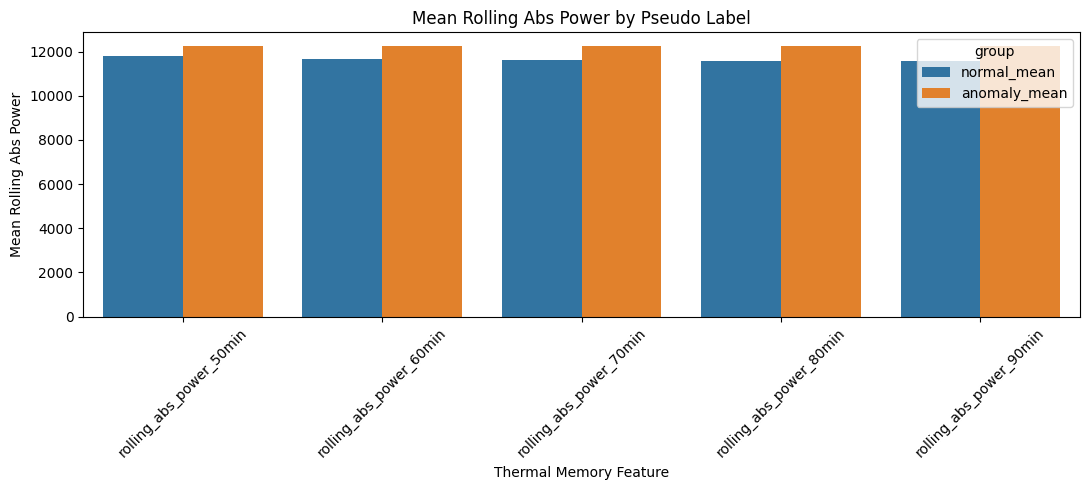

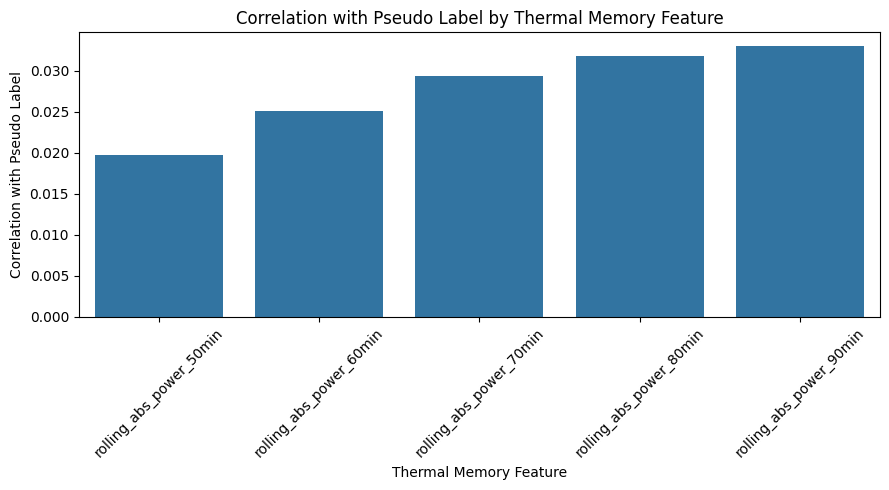

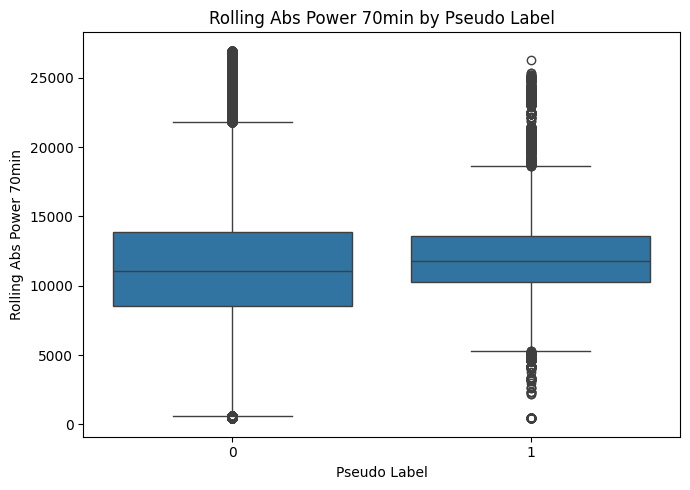

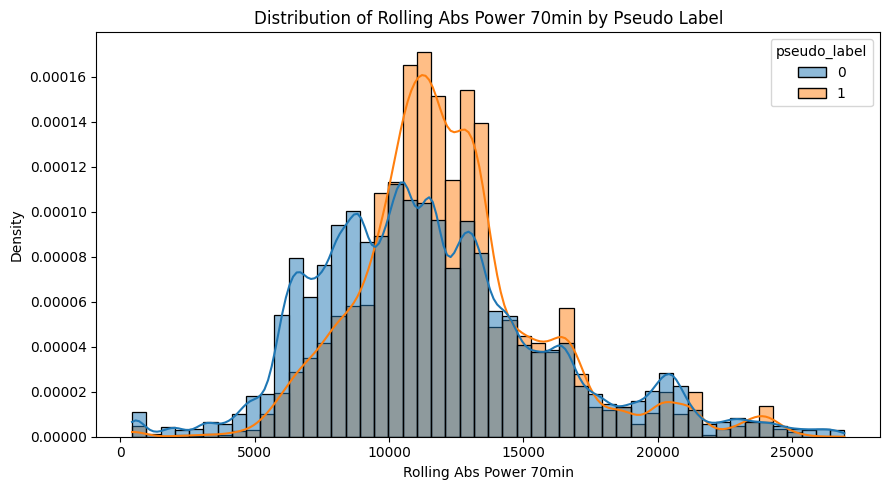

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# =========================
# 1. 데이터 준비
# =========================

df = analysis_df.copy()
df = df.sort_values(["source", "time"]).reset_index(drop=True)

print("초기 컬럼 확인:")
print(df.columns.tolist())

# =========================
# 2. pseudo_label 생성
# =========================

anomaly_features = [
    "voltage",
    "current",
    "battery_temp",
    "power",
    "delta_v",
    "delta_i",
    "delta_t_temp",
    "delta_p",
    "dv_dt",
    "di_dt",
    "dt_dt",
    "dp_dt",
    "temp_diff"
]

# 실제 존재하는 feature만 사용
anomaly_features = [col for col in anomaly_features if col in df.columns]

print("사용할 anomaly feature:")
print(anomaly_features)

# Z-score 기반 anomaly score 생성
for col in anomaly_features:
    mean = df[col].mean()
    std = df[col].std()

    if std == 0 or pd.isna(std):
        df[f"{col}_z"] = 0
    else:
        df[f"{col}_z"] = (df[col] - mean) / std

    df[f"{col}_anomaly_score"] = df[f"{col}_z"].abs()
    df[f"{col}_is_anomaly"] = (df[f"{col}_anomaly_score"] >= 3).astype(int)

# 이상 feature 개수
anomaly_flag_cols = [f"{col}_is_anomaly" for col in anomaly_features]

df["anomaly_feature_count"] = df[anomaly_flag_cols].sum(axis=1)

# pseudo_label 생성
# 하나 이상의 feature에서 |z| >= 3이면 이상 후보
df["pseudo_label"] = (df["anomaly_feature_count"] >= 1).astype(int)

print("\npseudo_label 생성 확인:")
print(df["pseudo_label"].value_counts())

# =========================
# 3. Thermal Memory Feature 생성
# =========================

df["abs_power"] = df["power"].abs()

dt = df["delta_t"].median()
rows_per_min = int(round(60 / dt))

print("\nMedian delta_t:", dt)
print("Rows per minute:", rows_per_min)

candidate_minutes = [50, 60, 70, 80, 90]

for minute in candidate_minutes:
    col = f"rolling_abs_power_{minute}min"
    window_size = minute * rows_per_min

    df[col] = (
        df
        .groupby("source")["abs_power"]
        .transform(
            lambda x: x.rolling(
                window=window_size,
                min_periods=1
            ).mean()
        )
    )

# =========================
# 4. pseudo_label별 Thermal Memory Feature 비교
# =========================

candidate_cols = [f"rolling_abs_power_{m}min" for m in candidate_minutes]

summary_list = []

for col in candidate_cols:
    normal = df.loc[df["pseudo_label"] == 0, col].dropna()
    anomaly = df.loc[df["pseudo_label"] == 1, col].dropna()

    normal_mean = normal.mean()
    anomaly_mean = anomaly.mean()

    normal_median = normal.median()
    anomaly_median = anomaly.median()

    mean_ratio = anomaly_mean / normal_mean
    median_ratio = anomaly_median / normal_median

    corr = df[[col, "pseudo_label"]].corr().iloc[0, 1]

    t_stat, p_value = ttest_ind(
        normal,
        anomaly,
        equal_var=False
    )

    pooled_std = np.sqrt(
        ((len(normal) - 1) * normal.std()**2 + (len(anomaly) - 1) * anomaly.std()**2)
        / (len(normal) + len(anomaly) - 2)
    )

    cohens_d = (anomaly_mean - normal_mean) / pooled_std

    summary_list.append({
        "feature": col,
        "normal_count": len(normal),
        "anomaly_count": len(anomaly),
        "normal_mean": normal_mean,
        "anomaly_mean": anomaly_mean,
        "mean_ratio_anomaly_normal": mean_ratio,
        "normal_median": normal_median,
        "anomaly_median": anomaly_median,
        "median_ratio_anomaly_normal": median_ratio,
        "corr_with_pseudo_label": corr,
        "p_value": p_value,
        "cohens_d": cohens_d
    })

pseudo_label_summary = pd.DataFrame(summary_list)

display(pseudo_label_summary)

# =========================
# 5. 가장 관련성 큰 feature 확인
# =========================

best_by_ratio = pseudo_label_summary.loc[
    pseudo_label_summary["mean_ratio_anomaly_normal"].idxmax()
]

best_by_corr = pseudo_label_summary.loc[
    pseudo_label_summary["corr_with_pseudo_label"].idxmax()
]

best_by_effect = pseudo_label_summary.loc[
    pseudo_label_summary["cohens_d"].idxmax()
]

print("\n이상/정상 평균 비율이 가장 큰 feature")
print(best_by_ratio)

print("\npseudo_label과 상관계수가 가장 큰 feature")
print(best_by_corr)

print("\nCohen's d가 가장 큰 feature")
print(best_by_effect)

# =========================
# 6. 평균 비교 그래프
# =========================

plot_df = pseudo_label_summary.melt(
    id_vars="feature",
    value_vars=["normal_mean", "anomaly_mean"],
    var_name="group",
    value_name="mean_value"
)

plt.figure(figsize=(11, 5))

sns.barplot(
    data=plot_df,
    x="feature",
    y="mean_value",
    hue="group"
)

plt.title("Mean Rolling Abs Power by Pseudo Label")
plt.xlabel("Thermal Memory Feature")
plt.ylabel("Mean Rolling Abs Power")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 7. pseudo_label과의 상관계수 그래프
# =========================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=pseudo_label_summary,
    x="feature",
    y="corr_with_pseudo_label"
)

plt.title("Correlation with Pseudo Label by Thermal Memory Feature")
plt.xlabel("Thermal Memory Feature")
plt.ylabel("Correlation with Pseudo Label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 8. 대표 feature 70분 기준 Boxplot
# =========================

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="pseudo_label",
    y="rolling_abs_power_70min"
)

plt.title("Rolling Abs Power 70min by Pseudo Label")
plt.xlabel("Pseudo Label")
plt.ylabel("Rolling Abs Power 70min")
plt.tight_layout()
plt.show()

# =========================
# 9. 대표 feature 70분 기준 분포 비교
# =========================

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="rolling_abs_power_70min",
    hue="pseudo_label",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Distribution of Rolling Abs Power 70min by Pseudo Label")
plt.xlabel("Rolling Abs Power 70min")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# =========================
# 1. 데이터 준비
# =========================

df = analysis_df.copy()

df = df.sort_values(["source", "time"]).reset_index(drop=True)

# 전력 부하 크기
df["abs_power"] = df["power"].abs()

# pseudo_label 확인
print("Pseudo-label count")
print(df["pseudo_label"].value_counts())

# 시간 간격 확인
dt = df["delta_t"].median()
rows_per_min = int(round(60 / dt))

print("Median delta_t:", dt)
print("Rows per minute:", rows_per_min)


# =========================
# 2. Thermal Memory Feature 생성
# =========================

candidate_minutes = [50, 60, 70, 80, 90]

for minute in candidate_minutes:
    col = f"rolling_abs_power_{minute}min"
    window_size = minute * rows_per_min
    
    df[col] = (
        df
        .groupby("source")["abs_power"]
        .transform(
            lambda x: x.rolling(
                window=window_size,
                min_periods=1
            ).mean()
        )
    )


# =========================
# 3. pseudo-label별 평균/중앙값 비교
# =========================

candidate_cols = [
    f"rolling_abs_power_{minute}min"
    for minute in candidate_minutes
]

summary_list = []

for col in candidate_cols:
    normal = df.loc[df["pseudo_label"] == 0, col].dropna()
    anomaly = df.loc[df["pseudo_label"] == 1, col].dropna()
    
    normal_mean = normal.mean()
    anomaly_mean = anomaly.mean()
    normal_median = normal.median()
    anomaly_median = anomaly.median()
    
    mean_ratio = anomaly_mean / normal_mean
    median_ratio = anomaly_median / normal_median
    
    corr = df[[col, "pseudo_label"]].corr().iloc[0, 1]
    
    t_stat, p_value = ttest_ind(
        normal,
        anomaly,
        equal_var=False
    )
    
    pooled_std = np.sqrt(
        ((len(normal) - 1) * normal.std()**2 + (len(anomaly) - 1) * anomaly.std()**2)
        / (len(normal) + len(anomaly) - 2)
    )
    
    cohens_d = (anomaly_mean - normal_mean) / pooled_std
    
    summary_list.append({
        "feature": col,
        "normal_count": len(normal),
        "anomaly_count": len(anomaly),
        "normal_mean": normal_mean,
        "anomaly_mean": anomaly_mean,
        "mean_ratio_anomaly_normal": mean_ratio,
        "normal_median": normal_median,
        "anomaly_median": anomaly_median,
        "median_ratio_anomaly_normal": median_ratio,
        "corr_with_pseudo_label": corr,
        "t_stat": t_stat,
        "p_value": p_value,
        "cohens_d": cohens_d
    })

pseudo_label_summary = pd.DataFrame(summary_list)

pseudo_label_summary

Pseudo-label count


KeyError: 'pseudo_label'

In [129]:
# =========================
# 4. 가장 관련성 큰 feature 확인
# =========================

best_by_ratio = pseudo_label_summary.loc[
    pseudo_label_summary["mean_ratio_anomaly_normal"].idxmax()
]

best_by_corr = pseudo_label_summary.loc[
    pseudo_label_summary["corr_with_pseudo_label"].idxmax()
]

best_by_effect = pseudo_label_summary.loc[
    pseudo_label_summary["cohens_d"].idxmax()
]

print("이상/정상 평균 비율이 가장 큰 feature")
print(best_by_ratio)

print("\npseudo_label과 상관계수가 가장 큰 feature")
print(best_by_corr)

print("\nCohen's d가 가장 큰 feature")
print(best_by_effect)

NameError: name 'pseudo_label_summary' is not defined

In [ ]:
# =========================
# 5. 평균 비교 그래프
# =========================

plot_df = pseudo_label_summary.melt(
    id_vars="feature",
    value_vars=["normal_mean", "anomaly_mean"],
    var_name="group",
    value_name="mean_value"
)

plt.figure(figsize=(11, 5))

sns.barplot(
    data=plot_df,
    x="feature",
    y="mean_value",
    hue="group"
)

plt.title("Mean Rolling Abs Power by Pseudo Label")
plt.xlabel("Thermal Memory Feature")
plt.ylabel("Mean Rolling Abs Power")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 6. pseudo-label과의 상관계수 그래프
# =========================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=pseudo_label_summary,
    x="feature",
    y="corr_with_pseudo_label"
)

plt.title("Correlation with Pseudo Label by Thermal Memory Feature")
plt.xlabel("Thermal Memory Feature")
plt.ylabel("Correlation with Pseudo Label")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 7. 대표 feature 70분 기준 Boxplot
# =========================

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="pseudo_label",
    y="rolling_abs_power_70min"
)

plt.title("Rolling Abs Power 70min by Pseudo Label")
plt.xlabel("Pseudo Label")
plt.ylabel("Rolling Abs Power 70min")

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 8. 대표 feature 70분 기준 분포 비교
# =========================

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="rolling_abs_power_70min",
    hue="pseudo_label",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Distribution of Rolling Abs Power 70min by Pseudo Label")
plt.xlabel("Rolling Abs Power 70min")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

In [132]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score
 
# =========================================================
# 1. Thermal Memory 생성
# =========================================================
 
# rolling_abs_power_70min 이미 있으면 생략 가능
# 예시: 1초 단위 데이터 기준이면 70*60 = 4200
 
# df['rolling_abs_power_70min'] = (
#     df['abs_power']
#     .rolling(window=4200, min_periods=1)
#     .mean()
# )
 
# =========================================================
# 2. Robust Z-score 함수
# =========================================================
 
def robust_zscore(series):
    median = series.median()
    mad = np.median(np.abs(series - median))
 
    # MAD 0 방지
    if mad == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
 
    return 0.6745 * (series - median) / mad
 
# =========================================================
# 3. Thermal Memory Stress 생성
# =========================================================
 
df['A_Thermal_Memory'] = np.abs(
    robust_zscore(df['rolling_abs_power_70min'])
)
 
# =========================================================
# 4. 기존 Joule Heating Stress 확인
# =========================================================
# 이미 있으면 생략
 
# 예시
# df['A_Joule_Heating_Stress']
 
# =========================================================
# 5. 8:2 비율 적용
# =========================================================
 
df['A_Thermal_Stress_New'] = (
    0.6 * df['A_Joule_Heating_Stress']
    +
    0.4 * df['A_Thermal_Memory']
)
 
# =========================================================
# 6. 새로운 BSI 계산
# =========================================================
 
df['BSI_New'] = (
    0.3140 * df['A_Delta_I']
    +
    0.2933 * df['A_Delta_P']
    +
    0.1442 * df['A_Delta_V']
    +
    0.0668 * df['A_Thermal_Stress_New']
    +
    0.0645 * df['A_Battery_Current']
    +
    0.0607 * df['A_Battery_Voltage']
    +
    0.0565 * df['A_Battery_Power']
)
 
# =========================================================
# 7. 기존 BSI (비교용)
# =========================================================
 
df['BSI_Original'] = (
    0.3140 * df['A_Delta_I']
    +
    0.2933 * df['A_Delta_P']
    +
    0.1442 * df['A_Delta_V']
    +
    0.0668 * df['A_Joule_Heating_Stress']
    +
    0.0645 * df['A_Battery_Current']
    +
    0.0607 * df['A_Battery_Voltage']
    +
    0.0565 * df['A_Battery_Power']
)
 
# =========================================================
# 8. Threshold 설정
# =========================================================
# 기존 threshold 있으면 그대로 사용
 
threshold = df['BSI_Original'].quantile(0.95)
 
df['Pred_Original'] = (df['BSI_Original'] > threshold).astype(int)
df['Pred_New'] = (df['BSI_New'] > threshold).astype(int)
 
# =========================================================
# 9. 성능 평가
# =========================================================
 
y_true = df['pseudo_label']
 
print("\n================ 기존 BSI =================")
print("Accuracy :", accuracy_score(y_true, df['Pred_Original']))
print("Precision:", precision_score(y_true, df['Pred_Original']))
print("Recall   :", recall_score(y_true, df['Pred_Original']))
print("F1 Score :", f1_score(y_true, df['Pred_Original']))
 
print("\n================ New BSI (8:2) =================")
print("Accuracy :", accuracy_score(y_true, df['Pred_New']))
print("Precision:", precision_score(y_true, df['Pred_New']))
print("Recall   :", recall_score(y_true, df['Pred_New']))
print("F1 Score :", f1_score(y_true, df['Pred_New']))
 
# =========================================================
# 10. BSI 분포 확인
# =========================================================
 
print("\nBSI Original")
print(df['BSI_Original'].describe())
 
print("\nBSI New")
print(df['BSI_New'].describe())

KeyError: 'A_Joule_Heating_Stress'